# Evaluating the output of the SCIP solver of CVXPY

In [1]:
from av_mat_generation.CI_based.window import Window
from datetime import datetime
import pandas as pd
import numpy as np
import cvxpy as cp
MAIN_FOLDER = 'availability_matrices/av-mat-extn-cifar10-23thFeb_2'

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/crodrigu/GreenFL/greenfl_venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/crodrigu/GreenFL/greenfl_venv/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/crodrigu/GreenFL/greenfl_venv/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/home/crodrigu/GreenFL/greenfl_venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/home/crodrigu/GreenFL/greenfl_venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 649, in get
    

In [2]:
start_time=datetime(2022, 1, 1, 0, 0)
win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=100)
res = win.get_GHG_matrix()
min_carbon_budget = res[[i for i in range(99,100)]].sum().sum()
total_cb = res.sum().sum()
print(1-min_carbon_budget/total_cb)
win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=100)

0.9880647818155418


In [3]:
carbon_budget_considered = res.sum().cumsum().to_numpy().take([89,74,59,44,29,14,4])
perc_cb_saved = [100*(i/total_cb) for i in carbon_budget_considered]
print(carbon_budget_considered)
print(perc_cb_saved)

[20.780553 15.540347999999996 11.732774999999997 8.838905999999998
 6.1960109999999995 3.032562 0.9428550000000001]
[86.03754606747044, 64.34157007056174, 48.57710810495588, 36.59564700520919, 25.653291413710384, 12.555690542858041, 3.903694502135956]


In [ ]:
ft=3
T = [90,75,60,45,30,15,5]
for CO2saving, carbon_budget in enumerate(carbon_budget_considered):
    print(T[CO2saving])
    for _in_val in [20,40,60,80,100]:
        win1 = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=T[CO2saving]+_in_val)
        win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=T[CO2saving]+_in_val-ft)
        
        # Compute new budget with idle time
        C_idle = 0.1
        GHG_mat = win1.GHG_matrix.to_numpy()
        print("x.----------------------- x")
        print("Budget: ", carbon_budget)
        # display(win1.GHG_matrix)
        # print(C_idle*np.sum(GHG_mat))
        new_carbon_budget = (carbon_budget - C_idle*np.sum(GHG_mat))/(1-C_idle)
        print("New Budget: ", new_carbon_budget)
        
        if new_carbon_budget >= 0:
            try:
                av_mat = win.get_av_mat(method='greedy', fine_tuning=False, carbon_budget=new_carbon_budget-win1.get_GHG_matrix().to_numpy()[:,-ft:].sum(), key_word=f"alphaF-{T[CO2saving]+_in_val}sl-{CO2saving+1}cb")
                availability_df = pd.DataFrame(np.hstack([av_mat.to_numpy(),np.ones((7,ft))]), index=win.countries, columns=[i for i in range(av_mat.shape[1]+ft)])
                key_word=f"alphaF-{T[CO2saving]+_in_val}sl-{CO2saving+1}cb-{ft}ft"
                dict_cols = dict(
                zip([i for i in range(win.n_rounds+ft)], win1.window_list_hours[:win.n_rounds+ft])
            )  # get the datetime values
                availability_matrix_to_save = availability_df.rename(columns=dict_cols)
                availability_matrix_to_save.to_csv(
                    win.out_folder + "/av-mat_" + key_word + ".csv",
                    columns=win1.window_list_hours[:win.n_rounds+ft],
                )
            except Exception as e:
                print(f"Failed! Exception: {e}")
                continue
    continue

In [4]:
ft=3
T = [90,75,60,45,30,15,5]
for CO2saving, carbon_budget in enumerate(carbon_budget_considered):
    for _in_val in [20,40,60,80,100]:
        win1 = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=T[CO2saving]+_in_val)
        win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=T[CO2saving]+_in_val-ft)
        
        # Compute new budget with idle time
        C_idle = 0.1
        GHG_mat = win1.GHG_matrix.to_numpy()
        new_carbon_budget = (carbon_budget - C_idle*np.sum(GHG_mat))/(1-C_idle)

        if new_carbon_budget >= 0:
            key_word=f"alphaF-{T[CO2saving]+_in_val}sl-{CO2saving+1}cb-{ft}ft"
            print(key_word)

alphaF-110sl-1cb-3ft
alphaF-130sl-1cb-3ft
alphaF-150sl-1cb-3ft
alphaF-170sl-1cb-3ft
alphaF-190sl-1cb-3ft
alphaF-95sl-2cb-3ft
alphaF-115sl-2cb-3ft
alphaF-135sl-2cb-3ft
alphaF-155sl-2cb-3ft
alphaF-175sl-2cb-3ft
alphaF-80sl-3cb-3ft
alphaF-100sl-3cb-3ft
alphaF-120sl-3cb-3ft
alphaF-140sl-3cb-3ft
alphaF-160sl-3cb-3ft
alphaF-65sl-4cb-3ft
alphaF-85sl-4cb-3ft
alphaF-105sl-4cb-3ft
alphaF-125sl-4cb-3ft
alphaF-145sl-4cb-3ft
alphaF-50sl-5cb-3ft
alphaF-70sl-5cb-3ft
alphaF-90sl-5cb-3ft
alphaF-110sl-5cb-3ft
alphaF-130sl-5cb-3ft
alphaF-35sl-6cb-3ft
alphaF-55sl-6cb-3ft
alphaF-75sl-6cb-3ft
alphaF-95sl-6cb-3ft
alphaF-115sl-6cb-3ft
alphaF-25sl-7cb-3ft
alphaF-45sl-7cb-3ft


In [5]:
carbon_budget_considered = res.sum().cumsum().to_numpy().take([89,74,59,44,29,14,4,2])
perc_cb_saved = [100*(i/total_cb) for i in carbon_budget_considered]
print(carbon_budget_considered)
print(perc_cb_saved)

[20.780553 15.540347999999996 11.732774999999997 8.838905999999998
 6.1960109999999995 3.032562 0.9428550000000001 0.5575350000000001]
[86.03754606747044, 64.34157007056174, 48.57710810495588, 36.59564700520919, 25.653291413710384, 12.555690542858041, 3.903694502135956, 2.3083573977423577]


90
x.----------------------- x
Budget:  20.780553
New Budget:  20.021911333333335


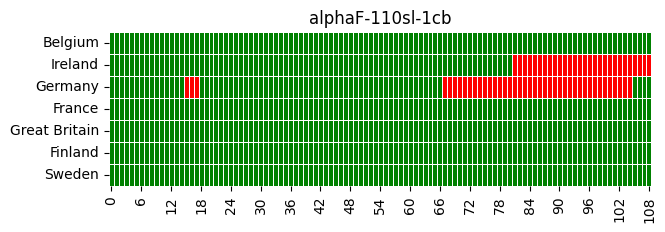

target:  19.665589333333337
result:  19.627512000000014
x.----------------------- x
Budget:  20.780553
New Budget:  19.226697333333334


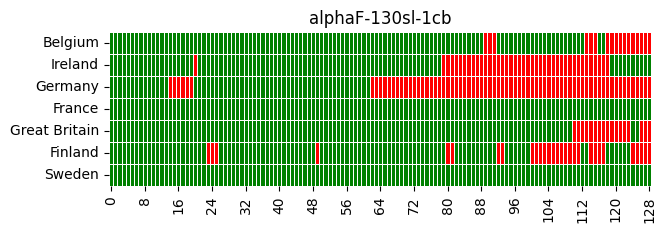

target:  18.847011333333334
result:  18.845025000000025
x.----------------------- x
Budget:  20.780553
New Budget:  18.517616000000004


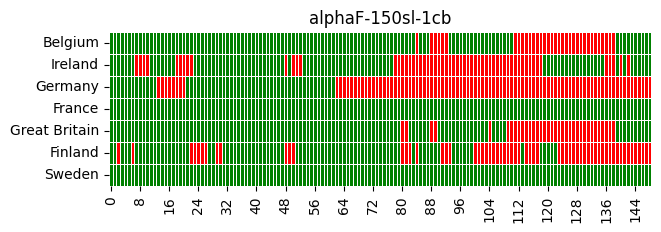

target:  18.239135000000005
result:  18.17598600000002
x.----------------------- x
Budget:  20.780553
New Budget:  17.727193000000003


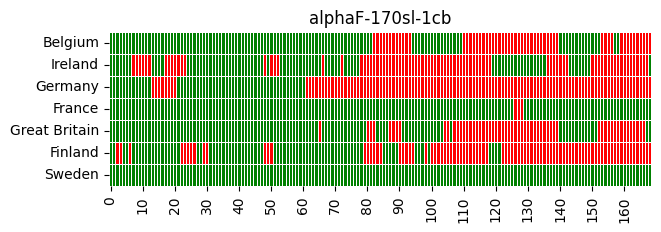

target:  17.407684000000003
result:  17.381385000000016
x.----------------------- x
Budget:  20.780553
New Budget:  17.07259166666667


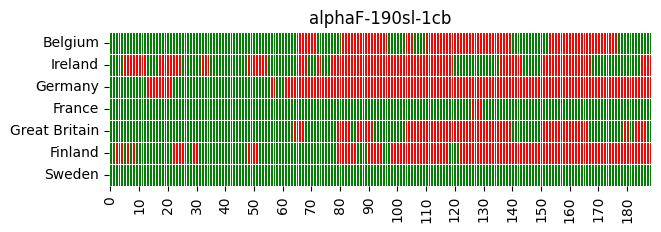

target:  16.827437666666672
result:  16.810794000000026
75
x.----------------------- x
Budget:  15.540347999999996
New Budget:  14.752888999999994


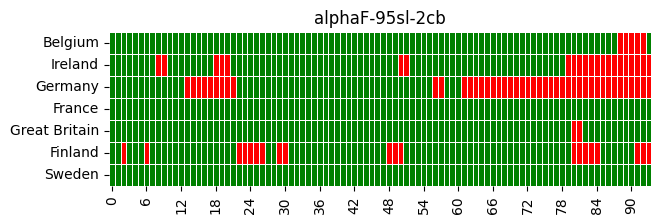

target:  14.408644999999995
result:  14.403282000000004
x.----------------------- x
Budget:  15.540347999999996
New Budget:  13.985176999999995


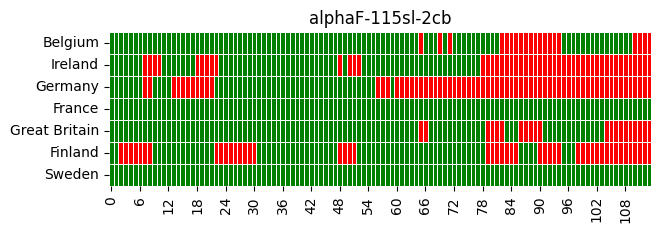

target:  13.595659999999995
result:  13.580007000000004
x.----------------------- x
Budget:  15.540347999999996
New Budget:  13.206070999999998


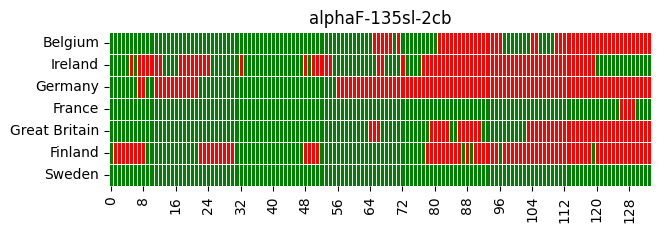

target:  12.844279999999998
result:  12.837825000000004
x.----------------------- x
Budget:  15.540347999999996
New Budget:  12.51221233333333


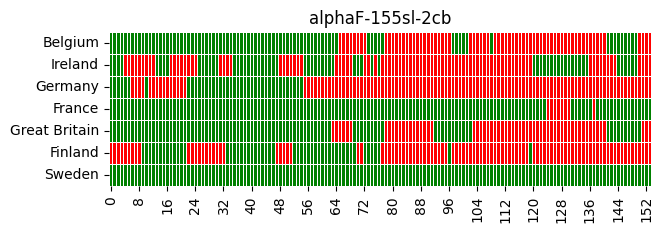

target:  12.16950733333333
result:  12.147236999999999
x.----------------------- x
Budget:  15.540347999999996
New Budget:  11.730607000000001


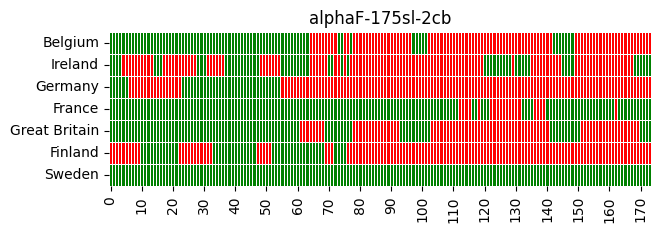

target:  11.416186000000001
result:  11.40894
60
x.----------------------- x
Budget:  11.732774999999997
New Budget:  11.142001999999996


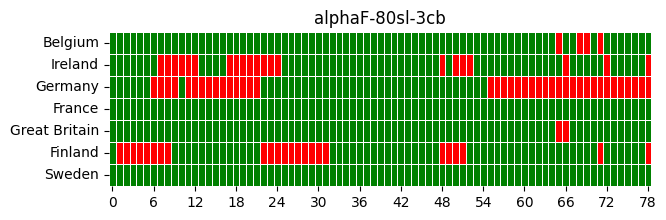

target:  10.797184999999995
result:  10.782777
x.----------------------- x
Budget:  11.732774999999997
New Budget:  10.35276233333333


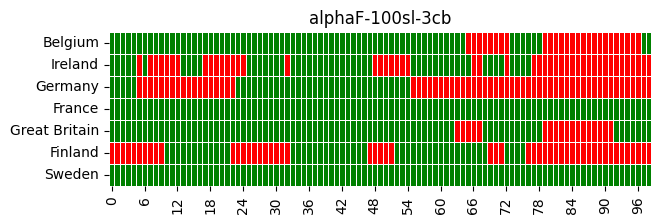

target:  10.064492333333328
result:  10.049975999999997
x.----------------------- x
Budget:  11.732774999999997
New Budget:  9.559476666666663


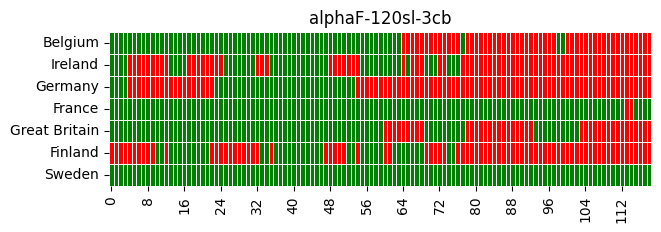

target:  9.246258666666662
result:  9.232064999999997
x.----------------------- x
Budget:  11.732774999999997
New Budget:  8.773903666666666


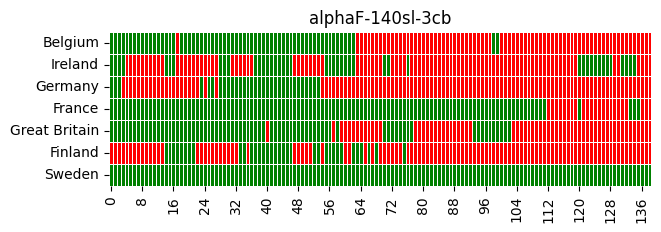

target:  8.440006666666665
result:  8.431184999999997
x.----------------------- x
Budget:  11.732774999999997
New Budget:  8.084284666666667


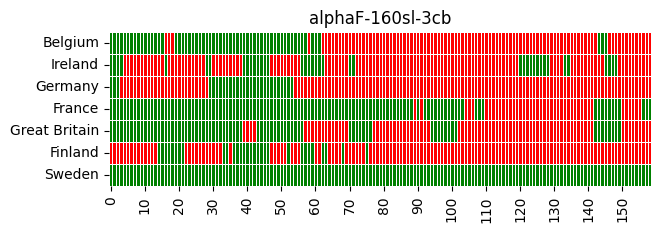

target:  7.710478666666667
result:  7.700726999999993
45
x.----------------------- x
Budget:  8.838905999999998
New Budget:  8.387173333333331


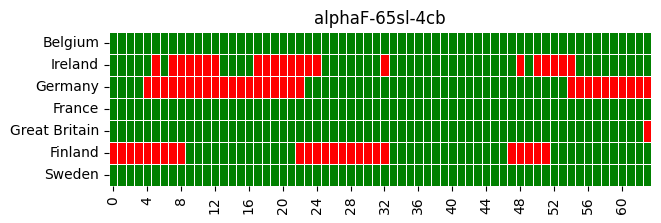

target:  8.127007333333331
result:  8.114684999999996
x.----------------------- x
Budget:  8.838905999999998
New Budget:  7.720496666666664


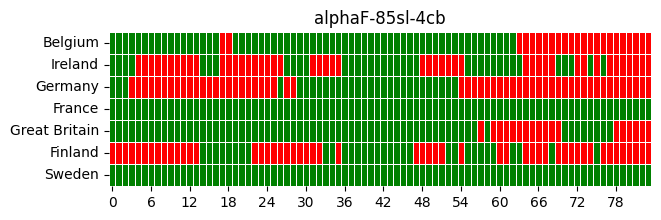

target:  7.346708666666664
result:  7.322288999999997
x.----------------------- x
Budget:  8.838905999999998
New Budget:  6.94987333333333


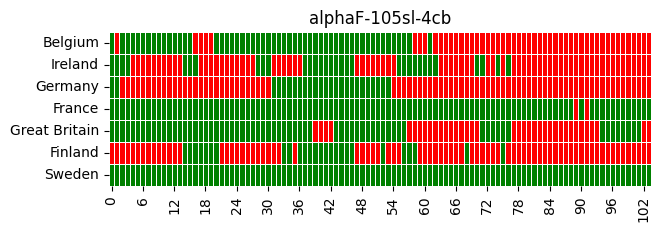

target:  6.58801333333333
result:  6.582365999999996
x.----------------------- x
Budget:  8.838905999999998
New Budget:  6.167425333333332


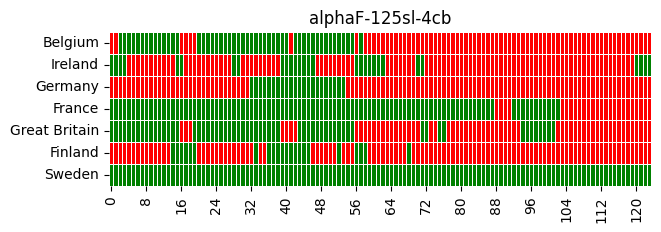

target:  5.835097333333332
result:  5.801660999999997
x.----------------------- x
Budget:  8.838905999999998
New Budget:  5.394725333333332


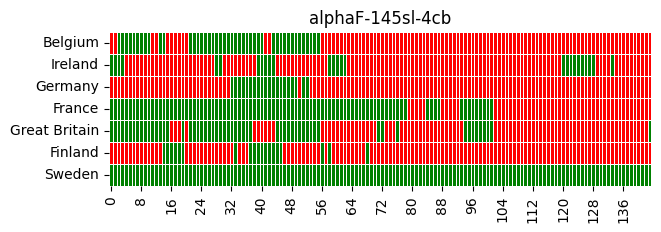

target:  5.125880333333332
result:  5.120957999999995
30
x.----------------------- x
Budget:  6.1960109999999995
New Budget:  5.803131666666666


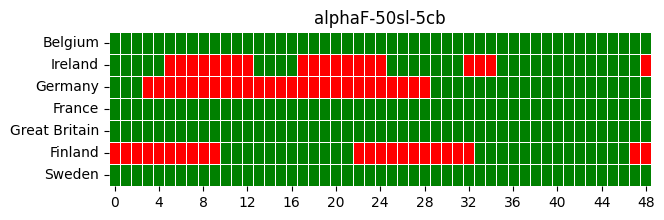

target:  5.615259666666667
result:  5.581631999999998
x.----------------------- x
Budget:  6.1960109999999995
New Budget:  5.302020333333333


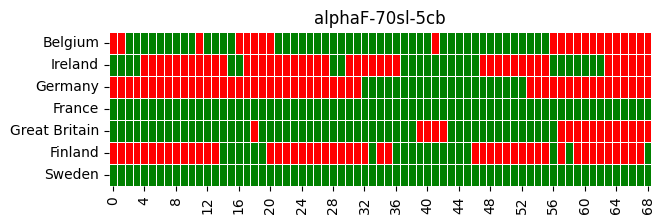

target:  5.040984333333333
result:  5.018903999999998
x.----------------------- x
Budget:  6.1960109999999995
New Budget:  4.575506333333332


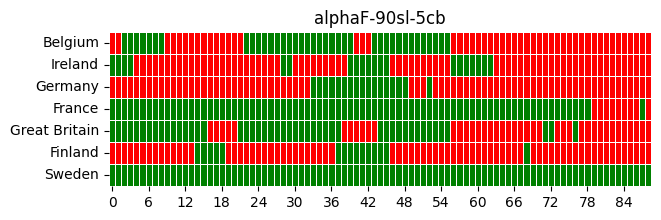

target:  4.187555333333332
result:  4.171943999999998
x.----------------------- x
Budget:  6.1960109999999995
New Budget:  3.816864666666666


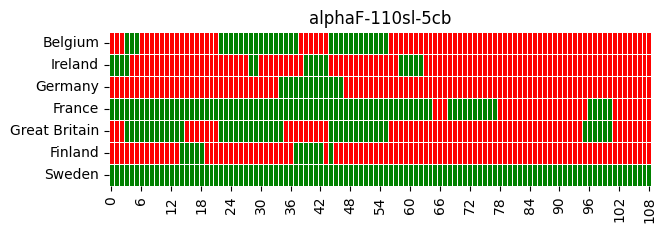

target:  3.460542666666666
result:  3.43038
x.----------------------- x
Budget:  6.1960109999999995
New Budget:  3.0216506666666665


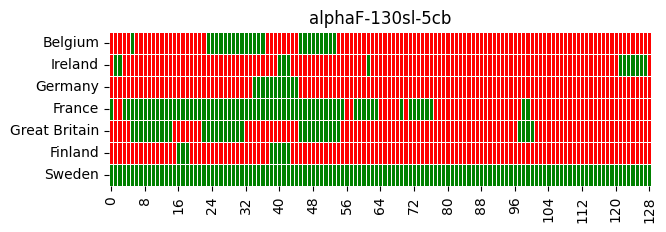

target:  2.6419646666666665
result:  2.6195400000000006
15
x.----------------------- x
Budget:  3.032562
New Budget:  2.5793723333333327


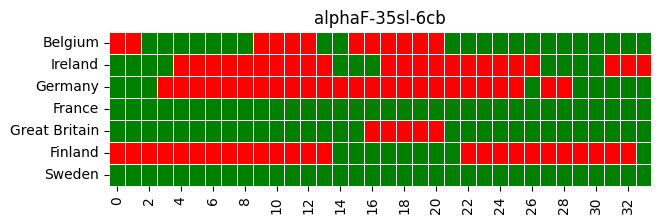

target:  2.4019013333333326
result:  2.393981999999999
x.----------------------- x
Budget:  3.032562
New Budget:  2.181952


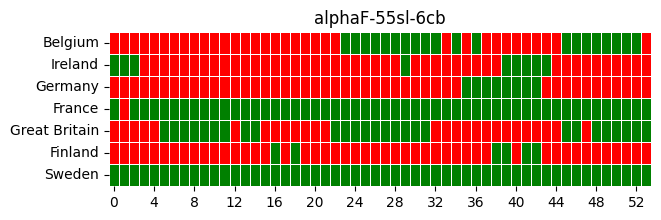

target:  1.9868169999999998
result:  1.982964
x.----------------------- x
Budget:  3.032562
New Budget:  1.6428079999999998


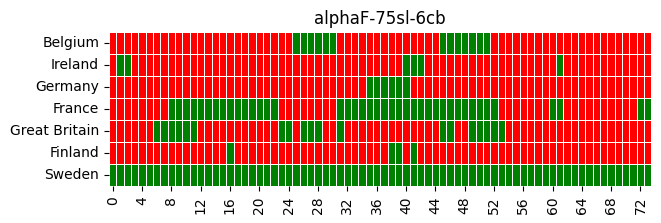

target:  1.381754
result:  1.378923
x.----------------------- x
Budget:  3.032562
New Budget:  0.8553489999999996


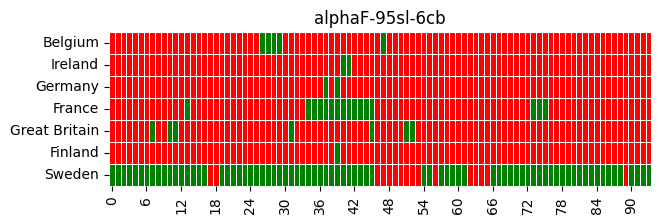

target:  0.5111049999999997
result:  0.472674
x.----------------------- x
Budget:  3.032562
New Budget:  0.08763699999999967


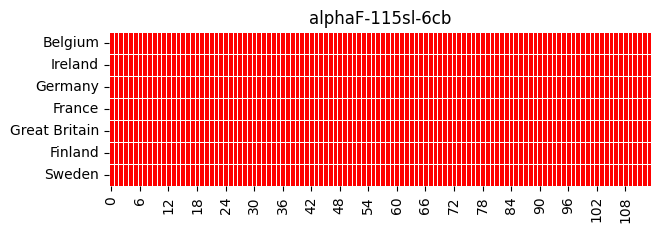

target:  -0.30188000000000026
result:  0.0
5
x.----------------------- x
Budget:  0.9428550000000001
New Budget:  0.4610546666666668


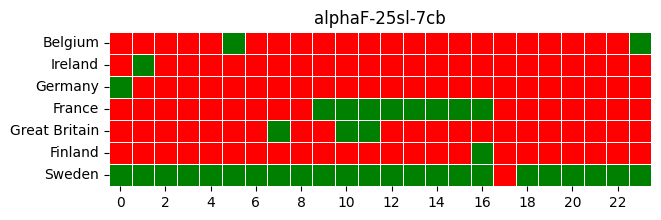

target:  0.2665616666666668
result:  0.26285699999999995
x.----------------------- x
Budget:  0.9428550000000001
New Budget:  0.06551600000000016


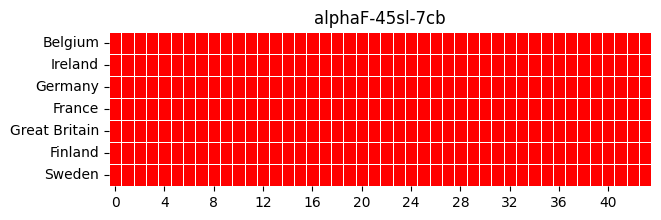

target:  -0.10337799999999983
result:  0.0
x.----------------------- x
Budget:  0.9428550000000001
New Budget:  -0.38621666666666665
x.----------------------- x
Budget:  0.9428550000000001
New Budget:  -1.052893333333333
x.----------------------- x
Budget:  0.9428550000000001
New Budget:  -1.8235166666666671
3
x.----------------------- x
Budget:  0.5575350000000001
New Budget:  0.07653666666666695


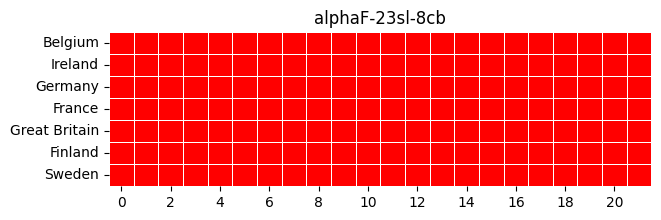

target:  -0.13034033333333306
result:  0.0
x.----------------------- x
Budget:  0.5575350000000001
New Budget:  -0.32475733333333334
x.----------------------- x
Budget:  0.5575350000000001
New Budget:  -0.757954333333333
x.----------------------- x
Budget:  0.5575350000000001
New Budget:  -1.3979366666666664
x.----------------------- x
Budget:  0.5575350000000001
New Budget:  -2.171383333333333


In [6]:
ft=1
T = [90,75,60,45,30,15,5,3]
for CO2saving, carbon_budget in enumerate(carbon_budget_considered):
    print(T[CO2saving])
    for _in_val in [20,40,60,80,100]:
        win1 = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=T[CO2saving]+_in_val)
        win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=T[CO2saving]+_in_val-ft)
        
        # Compute new budget with idle time
        C_idle = 0.1
        GHG_mat = win1.GHG_matrix.to_numpy()
        print("x.----------------------- x")
        print("Budget: ", carbon_budget)
        # display(win1.GHG_matrix)
        # print(C_idle*np.sum(GHG_mat))
        new_carbon_budget = (carbon_budget - C_idle*np.sum(GHG_mat))/(1-C_idle)
        print("New Budget: ", new_carbon_budget)
        
        if new_carbon_budget >= 0:
            try:
                av_mat = win.get_av_mat(method='greedy', fine_tuning=False, carbon_budget=new_carbon_budget-win1.get_GHG_matrix().to_numpy()[:,-ft:].sum(), key_word=f"alphaF-{T[CO2saving]+_in_val}sl-{CO2saving+1}cb")
                availability_df = pd.DataFrame(np.hstack([av_mat.to_numpy(),np.ones((7,ft))]), index=win.countries, columns=[i for i in range(av_mat.shape[1]+ft)])
                key_word=f"alphaF-{T[CO2saving]+_in_val}sl-{CO2saving+1}cb-{ft}ft"
                dict_cols = dict(
                zip([i for i in range(win.n_rounds+ft)], win1.window_list_hours[:win.n_rounds+ft])
            )  # get the datetime values
                availability_matrix_to_save = availability_df.rename(columns=dict_cols)
                availability_matrix_to_save.to_csv(
                    win.out_folder + "/av-mat_" + key_word + ".csv",
                    columns=win1.window_list_hours[:win.n_rounds+ft],
                )
            except Exception as e:
                print(f"Failed! Exception: {e}")
                continue
    continue

In [7]:
ft=1
T = [90,75,60,45,30,15,5,3]
for CO2saving, carbon_budget in enumerate(carbon_budget_considered):
    for _in_val in [20,40,60,80,100]:
        win1 = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=T[CO2saving]+_in_val)
        win = Window(start_time=start_time,random_start=False, out_folder=MAIN_FOLDER, \
            countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"], n_rounds=T[CO2saving]+_in_val-ft)
        
        # Compute new budget with idle time
        C_idle = 0.1
        GHG_mat = win1.GHG_matrix.to_numpy()
        new_carbon_budget = (carbon_budget - C_idle*np.sum(GHG_mat))/(1-C_idle)
        
        if new_carbon_budget >= 0:
            key_word=f"alphaF-{T[CO2saving]+_in_val}sl-{CO2saving+1}cb-{ft}ft"
            print(key_word)

alphaF-110sl-1cb-1ft
alphaF-130sl-1cb-1ft
alphaF-150sl-1cb-1ft
alphaF-170sl-1cb-1ft
alphaF-190sl-1cb-1ft
alphaF-95sl-2cb-1ft
alphaF-115sl-2cb-1ft
alphaF-135sl-2cb-1ft
alphaF-155sl-2cb-1ft
alphaF-175sl-2cb-1ft
alphaF-80sl-3cb-1ft
alphaF-100sl-3cb-1ft
alphaF-120sl-3cb-1ft
alphaF-140sl-3cb-1ft
alphaF-160sl-3cb-1ft
alphaF-65sl-4cb-1ft
alphaF-85sl-4cb-1ft
alphaF-105sl-4cb-1ft
alphaF-125sl-4cb-1ft
alphaF-145sl-4cb-1ft
alphaF-50sl-5cb-1ft
alphaF-70sl-5cb-1ft
alphaF-90sl-5cb-1ft
alphaF-110sl-5cb-1ft
alphaF-130sl-5cb-1ft
alphaF-35sl-6cb-1ft
alphaF-55sl-6cb-1ft
alphaF-75sl-6cb-1ft
alphaF-95sl-6cb-1ft
alphaF-115sl-6cb-1ft
alphaF-25sl-7cb-1ft
alphaF-45sl-7cb-1ft
alphaF-23sl-8cb-1ft
